In [1]:
# Step 1: Install YOLOv8
!pip install ultralytics --upgrade

# Step 2: Install Kaggle API to download dataset
!pip install kaggle

# Step 3: Upload your Kaggle API token
from google.colab import files
files.upload()  # upload kaggle.json

# Step 4: Set up Kaggle API credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 5: Download your dataset
!kaggle datasets download -d kriisanfarmer/guaallyolov8
!unzip guaallyolov8.zip -d /content/dataset

# Step 6: Check dataset structure
!ls /content/dataset

# Step 7: Prepare YOLOv8 YAML config
yaml_content = """
train: /content/dataset/data/train
val: /content/dataset/data/valid
test: /content/dataset/data/test

nc: 9
names:
  - algal_leaf_spot
  - black_mold
  - fruit_healthy
  - healthy_leaf
  - insect_bite
  - red_rust
  - scab
  - scorch
  - yellow_leaf_disease
"""
with open("/content/dataset/leaf_data.yaml", "w") as f:
    f.write(yaml_content)

# Step 8: Train YOLOv8
from ultralytics import YOLO

# Load model (you can use yolov8n, yolov8s, yolov8m, yolov8l, yolov8x)
model = YOLO("yolov8n.pt")  # tiny model for faster training

# Train the model
model.train(
    data="/content/dataset/leaf_data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="leaf_yolov8_training",
    name="yolov8_leaf",
    device=0
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.1 MB/s eta 0:00:00


Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/data/train/labels/scab0153ff_jpg.rf.c552032f75e06de93532cfc5204ae87a.txt  
  inflating: /content/dataset/data/train/labels/scab0153ff_jpg.rf.c552032f75e06de93532cfc5204ae87a_dup111.txt  
  inflating: /content/dataset/data/train/labels/scab0153ff_jpg.rf.c552032f75e06de93532cfc5204ae87a_dup576.txt  
  inflating: /content/dataset/data/train/labels/scab0153ff_jpg.rf.c552032f75e06de93532cfc5204ae87a_dup654.txt  
  inflating: /content/dataset/data/train/labels/scab0153ff_jpg.rf.eb2ca558c6726ba373aeaec510756bb1.txt  
  inflating: /content/dataset/data/train/labels/scab0153ff_jpg.rf.eb2ca558c6726ba373aeaec510756bb1_dup172.txt  
  inflating: /content/dataset/data/train/labels/scab0154ff_jpg.rf.02d3786424340e9e178f2051f568aec5.txt  
  inflating: /content/dataset/data/train/labels/scab0154ff_jpg.rf.45419981140f48c82213fb2748ed383a.txt  
  inflating: /content/dataset/data/train/labels/scab0154ff_jpg.rf.45419981140f48c

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a1c0c0ca360>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

In [3]:
import shutil
from google.colab import files

# Path to your training output folder
train_folder = "/content/leaf_yolov8_training/yolov8_leaf"

# Optional: check folder contents
!ls {train_folder}

# Create a zip archive of the whole training folder
shutil.make_archive("/content/leaf_yolov8_all", 'zip', train_folder)

# Download the zip file
files.download("/content/leaf_yolov8_all.zip")


args.yaml			 results	       train_batch2.jpg
BoxF1_curve.png			 results.csv	       val_batch0_labels.jpg
BoxP_curve.png			 results.png	       val_batch0_pred.jpg
BoxPR_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxR_curve.png			 train_batch1.jpg      val_batch1_pred.jpg
confusion_matrix_normalized.png  train_batch22520.jpg  val_batch2_labels.jpg
confusion_matrix.png		 train_batch22521.jpg  val_batch2_pred.jpg
labels.jpg			 train_batch22522.jpg  weights


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving images (21).jpg to images (21).jpg

image 1/1 /content/images (21).jpg: 416x640 (no detections), 45.1ms
Speed: 2.2ms preprocess, 45.1ms inference, 0.6ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /content/runs/detect/predict14


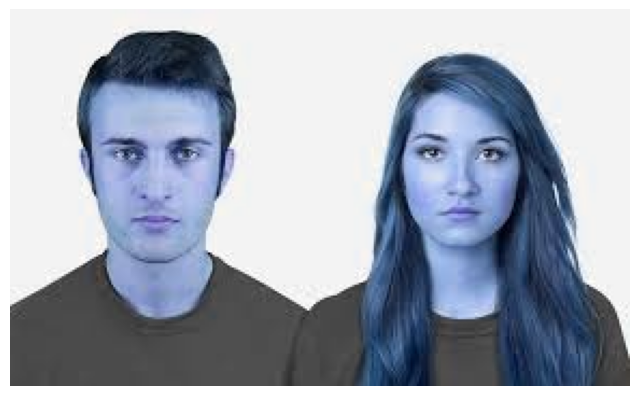

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
from ultralytics import YOLO
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt

# 1️⃣ Load your trained model
model_path = "/content/leaf_yolov8_training/yolov8_leaf/weights/best.pt"
model = YOLO(model_path)

# 2️⃣ Upload an image to test
uploaded = files.upload()  # Choose the image file

# Get the uploaded file name
img_path = list(uploaded.keys())[0]

# 3️⃣ Run detection
results = model.predict(img_path, save=True)  # save=True saves result image

# 4️⃣ Display the result
result_img_path = results[0].plot()  # get plotted image
plt.figure(figsize=(8,8))
plt.imshow(result_img_path)
plt.axis('off')
plt.show()

# 5️⃣ Optional: download the result image
result_save_path = "/content/detected_result.jpg"
Image.fromarray(result_img_path).save(result_save_path)
files.download(result_save_path)
